In [8]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
#EDA

data = pd.read_csv("/home/tuong/Job/data /cleaned_dataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5364 entries, 0 to 5363
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Tên KH    5364 non-null   str    
 1   Facebook  5364 non-null   str    
 2   SĐT       5364 non-null   int64  
 3   SĐT 2     2329 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 167.8 KB


In [9]:
# Check for missing values
print(data.isnull().sum())

Tên KH         0
Facebook       0
SĐT            0
SĐT 2       3035
dtype: int64


In [10]:
# giữ 3 cột cần thiết
data = data[["Tên KH", "Facebook", "SĐT"]]
data.isnull().sum()

Tên KH      0
Facebook    0
SĐT         0
dtype: int64

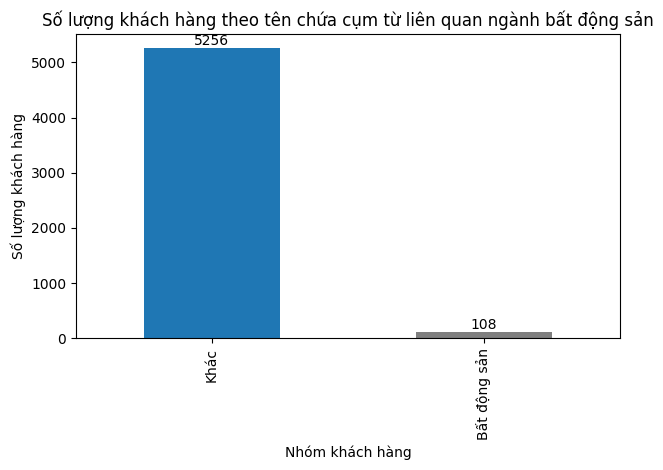

In [14]:
import re
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/home/tuong/Job/data /cleaned_dataset.csv")
data = data[["Tên KH", "Facebook", "SĐT"]].dropna(subset=["Tên KH"])

keywords = [
    "bất động sản", "bds", "địa ốc", "nhà đất",
    "công ty", "doanh nghiệp", "xây dựng",
    "kiến trúc", "nội thất"
]
pattern = "|".join(re.escape(k) for k in keywords)

mask = data["Tên KH"].str.lower().str.contains(pattern)
counts = mask.value_counts().rename(index={True: "Bất động sản", False: "Khác"})

ax = counts.plot(kind="bar", color=["tab:blue", "tab:gray"])
ax.set_xlabel("Nhóm khách hàng")
ax.set_ylabel("Số lượng khách hàng")
ax.set_title("Số lượng khách hàng theo tên chứa cụm từ liên quan ngành bất động sản")

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

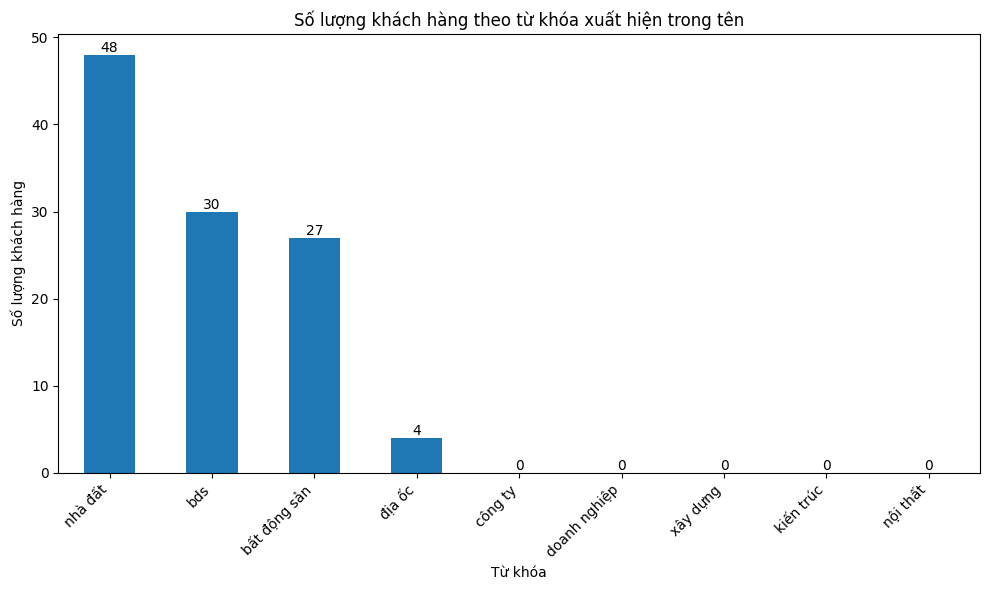

In [19]:
import re
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/home/tuong/Job/data /cleaned_dataset.csv")
data = data[["Tên KH"]].dropna()
data["lower_name"] = data["Tên KH"].str.lower()

keywords = [
    "bất động sản", "bds", "địa ốc", "nhà đất",
    "công ty", "doanh nghiệp", "xây dựng",
    "kiến trúc", "nội thất"
]

counts = {
    kw: data["lower_name"].str.contains(re.escape(kw)).sum()
    for kw in keywords
}
counts_series = pd.Series(counts).sort_values(ascending=False)

ax = counts_series.plot(kind="bar", color="tab:blue", figsize=(10, 6))
ax.set_xlabel("Từ khóa")
ax.set_ylabel("Số lượng khách hàng")
ax.set_title("Số lượng khách hàng theo từ khóa xuất hiện trong tên")
ax.set_xticklabels(counts_series.index, rotation=45, ha="right")

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

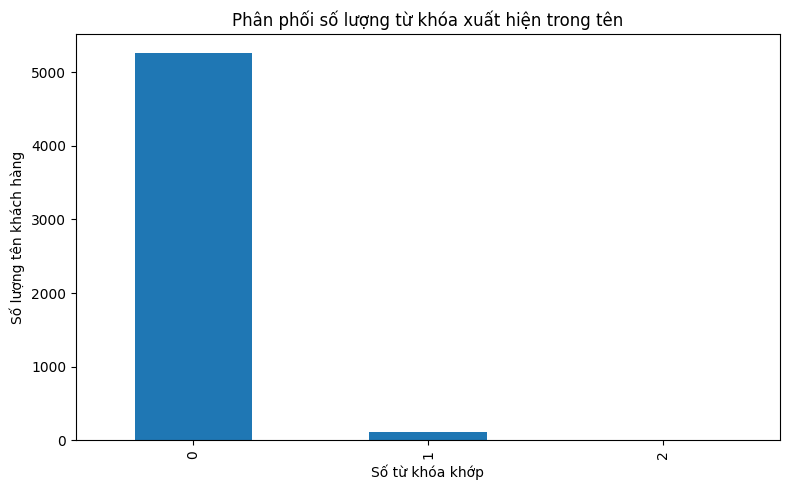

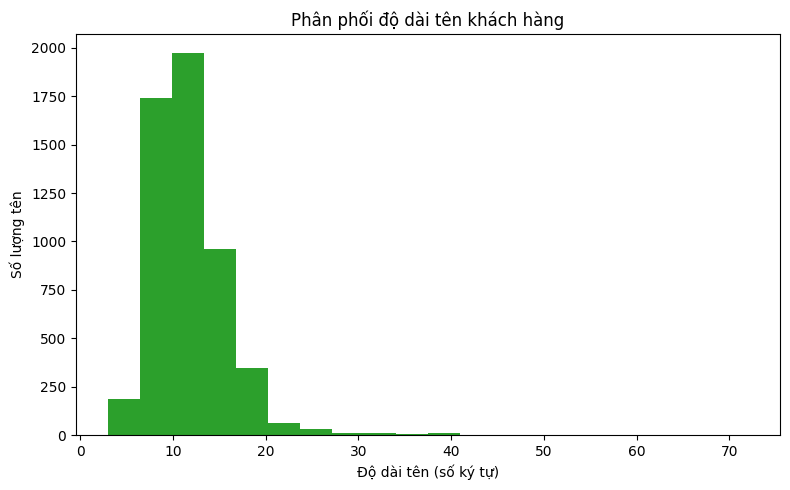

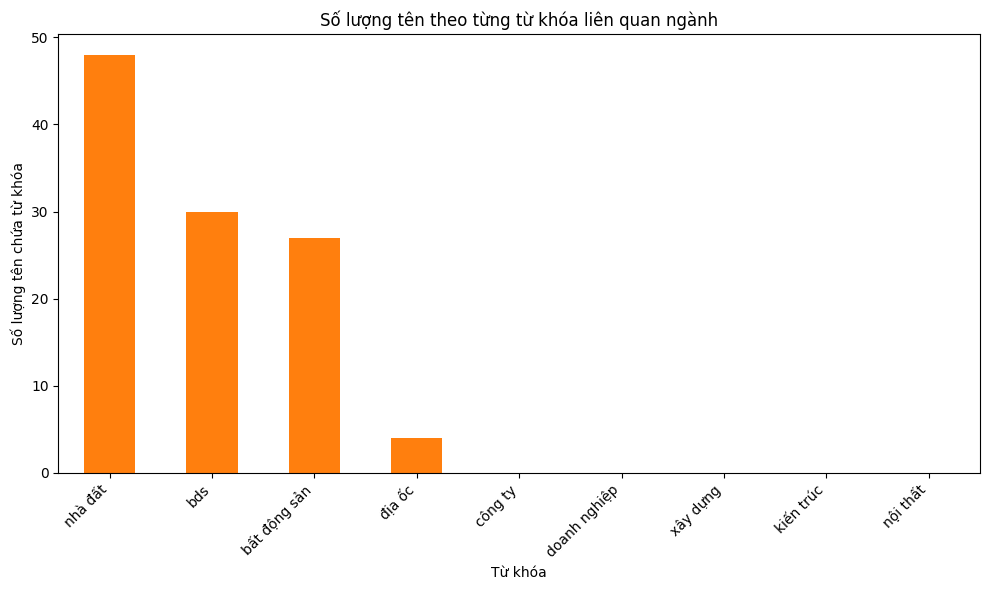

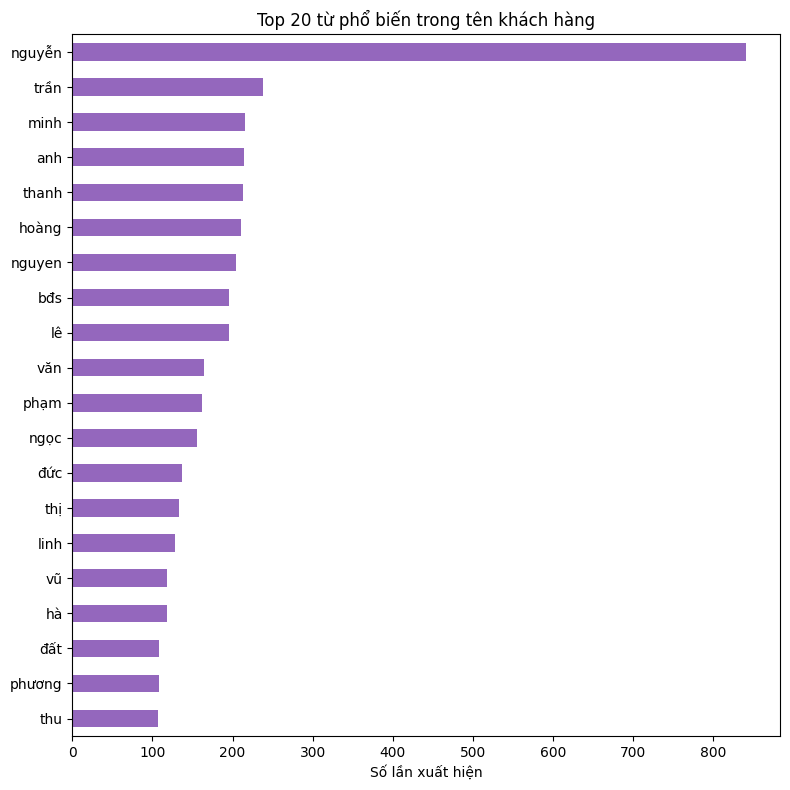

In [21]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/home/tuong/Job/data /cleaned_dataset.csv")
data = data[["Tên KH"]].dropna().copy()
data["lower_name"] = data["Tên KH"].str.lower()

keywords = [
    "bất động sản", "bds", "địa ốc", "nhà đất",
    "công ty", "doanh nghiệp", "xây dựng",
    "kiến trúc", "nội thất"
]

# 1. Số từ khóa tìm được trong mỗi tên
data["matches"] = data["lower_name"].apply(
    lambda x: [kw for kw in keywords if kw in x]
)
data["match_count"] = data["matches"].apply(len)

ax = data["match_count"].value_counts().sort_index().plot(
    kind="bar", color="tab:blue", figsize=(8, 5)
)
ax.set_xlabel("Số từ khóa khớp")
ax.set_ylabel("Số lượng tên khách hàng")
ax.set_title("Phân phối số lượng từ khóa xuất hiện trong tên")
plt.tight_layout()
plt.show()

# 2. Độ dài tên (số ký tự)
ax = data["lower_name"].str.len().plot(
    kind="hist", bins=20, color="tab:green", figsize=(8, 5)
)
ax.set_xlabel("Độ dài tên (số ký tự)")
ax.set_ylabel("Số lượng tên")
ax.set_title("Phân phối độ dài tên khách hàng")
plt.tight_layout()
plt.show()

# 3. Số lượng tên chứa từng keyword
keyword_counts = {
    kw: data["lower_name"].str.contains(re.escape(kw)).sum()
    for kw in keywords
}
counts_series = pd.Series(keyword_counts).sort_values(ascending=False)

ax = counts_series.plot(
    kind="bar", color="tab:orange", figsize=(10, 6)
)
ax.set_xlabel("Từ khóa")
ax.set_ylabel("Số lượng tên chứa từ khóa")
ax.set_title("Số lượng tên theo từng từ khóa liên quan ngành")
ax.set_xticklabels(counts_series.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 4. Tần suất từ phổ biến trong tên
stopwords = {
    "của", "và", "công", "ty", "cty", "vd", "vn", "thành", "phố",
    "quận", "huyện", "tp", "đt", "sđt"
}
words = Counter(
    word
    for name in data["lower_name"]
    for word in re.findall(r"\w+", name)
    if word not in stopwords
)
top_words = pd.Series(dict(words.most_common(20)))

ax = top_words.sort_values().plot(
    kind="barh", color="tab:purple", figsize=(8, 8)
)
ax.set_xlabel("Số lần xuất hiện")
ax.set_title("Top 20 từ phổ biến trong tên khách hàng")
plt.tight_layout()
plt.show()